# Filtro Hodrick-Prescott desde Cero

## Una Exploración Pausada y Reflexiva

En este notebook vamos a implementar el **filtro Hodrick-Prescott (HP)** manualmente, sin usar librerías especializadas. Es un ejercicio de paciencia y comprensión profunda de qué es realmente un ciclo económico.

El filtro HP es una técnica de descomposición que separa una serie de tiempo en:
- **Tendencia de largo plazo** (el componente suave)
- **Ciclo económico** (las fluctuaciones alrededor de la tendencia)

Vamos a hacerlo lentamente, paso a paso, entendiendo cada operación matemática que realizamos.

In [1]:
from pathlib import Path

# ============================================================================
# Paths & Folders - Root Detection & Directory Setup
# ============================================================================

# Detectar ROOT buscando la carpeta data/
current = Path.cwd()
ROOT = None
for parent in [current] + list(current.parents):
    if (parent / 'data').exists():
        ROOT = parent
        break

if ROOT is None:
    # Si estamos corriendo desde el notebook, usar su directorio padre
    ROOT = Path(__file__).parent.parent if '__file__' in dir() else current.parent

# Definir paths absolutos robustos
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
OUT_FIG = ROOT / 'outputs' / 'figures'
OUT_TAB = ROOT / 'outputs' / 'tables'
OUT_EXP = ROOT / 'outputs' / 'exports'

# Crear directorios de outputs si no existen
for path in [OUT_FIG, OUT_TAB, OUT_EXP]:
    path.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("ROOT DETECTION & PATHS CONFIGURATION")
print("=" * 70)
print(f"\nROOT: {ROOT}")
print(f"DATA_RAW:  {DATA_RAW}")
print(f"DATA_PROC: {DATA_PROC}")
print(f"OUT_FIG:   {OUT_FIG}")
print(f"OUT_TAB:   {OUT_TAB}")
print(f"OUT_EXP:   {OUT_EXP}")
print("\n✓ All output directories created/verified")

ROOT DETECTION & PATHS CONFIGURATION

ROOT: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos
DATA_RAW:  /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/data/raw
DATA_PROC: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/data/processed
OUT_FIG:   /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/figures
OUT_TAB:   /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/tables
OUT_EXP:   /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/exports

✓ All output directories created/verified


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configuramos los gráficos para que se vean bonitos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## Paso 1: Cargando los Datos

Vamos a cargar el archivo Excel con los datos trimestrales del PIB. Este será nuestro punto de partida: una serie de tiempo que contiene tanto la tendencia como los ciclos que queremos descomponer.

In [3]:
# Cargamos el archivo Excel
ruta_datos = DATA_PROC / 'GDP.xlsx'
df = pd.read_excel(ruta_datos, sheet_name='Quarterly')

print("Datos cargados exitosamente")
print(f"\nDimensiones: {df.shape[0]} observaciones × {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
print(df.head(10))

Datos cargados exitosamente

Dimensiones: 315 observaciones × 2 columnas

Primeras filas:
  observation_date      GDP
0       1947-01-01  243.164
1       1947-04-01  245.968
2       1947-07-01  249.585
3       1947-10-01  259.745
4       1948-01-01  265.742
5       1948-04-01  272.567
6       1948-07-01  279.196
7       1948-10-01  280.366
8       1949-01-01  275.034
9       1949-04-01  271.351


### Visualizando la Serie Original

Antes de procesarla, veamos qué tenemos. Esta es nuestra materia prima: una serie de PIB con tendencia creciente y fluctuaciones cíclicas.

In [3]:
# Identificamos la columna con los valores del PIB
print("Columnas disponibles:", df.columns.tolist())
print("\nInfo del dataframe:")
print(df.info())

Columnas disponibles: ['observation_date', 'GDP']

Info del dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  315 non-null    datetime64[us]
 1   GDP               315 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.1 KB
None


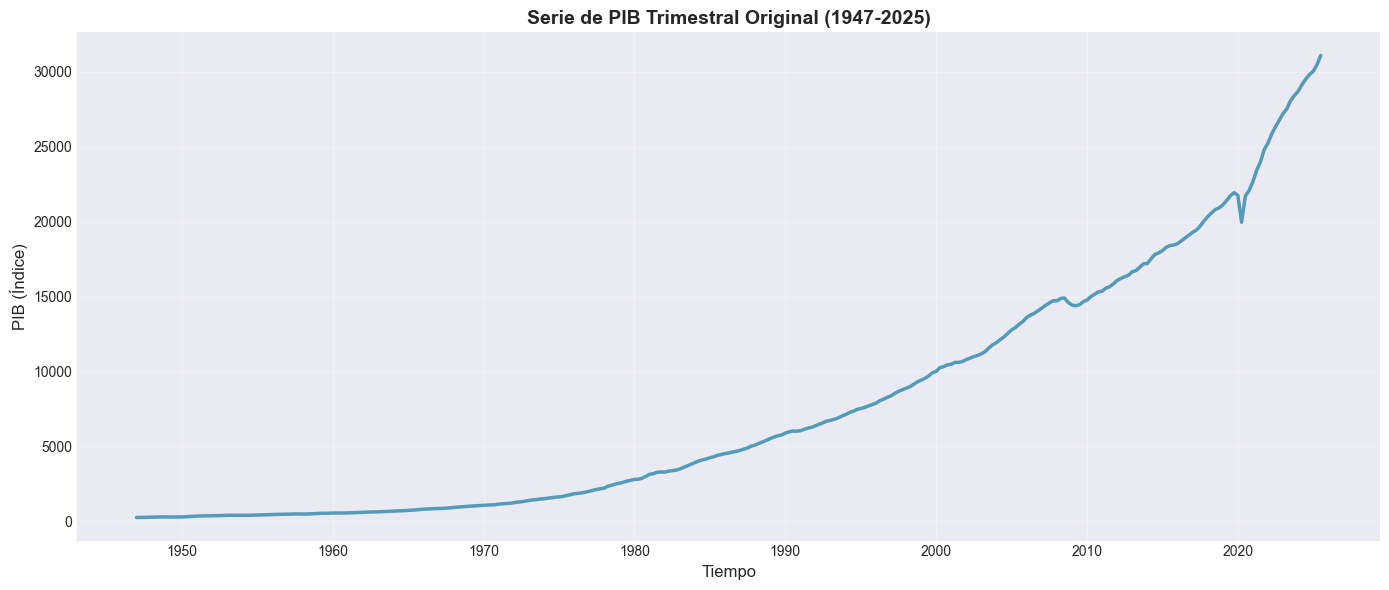

✓ Serie cargada: 315 observaciones trimestrales desde 1947 a 2025


In [5]:
# Extraemos la serie de PIB
y = df['GDP'].values
fechas = df['observation_date'].values

# Creamos un gráfico simple pero claro
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(fechas, y, linewidth=2.5, color='#2E86AB', alpha=0.8)
ax.set_title('Serie de PIB Trimestral Original (1947-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo', fontsize=12)
ax.set_ylabel('PIB (Índice)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Serie cargada: {len(y)} observaciones trimestrales desde 1947 a 2025")

## Paso 2: Entendiendo el Filtro Hodrick-Prescott

El filtro HP es un método de **suavización** que descompone nuestra serie en dos partes:

- **Tendencia (g)**: La trayectoria suave, de largo plazo
- **Ciclo (c)**: Las desviaciones de la tendencia

### La Fórmula Matemática

El filtro HP minimiza la siguiente expresión:

$$\min_g \sum_{t=1}^{T} (y_t - g_t)^2 + \lambda \sum_{t=2}^{T-1} (g_{t+1} - 2g_t + g_{t-1})^2$$

Donde:
- **y_t**: El valor observado en el período t
- **g_t**: La tendencia estimada en el período t  
- **λ (lambda)**: El parámetro de suavización

### Interpretación Intuitiva

- El **primer término** $(y_t - g_t)^2$ penaliza desviaciones de la tendencia (que sean muy grandes)
- El **segundo término** $(g_{t+1} - 2g_t + g_{t-1})^2$ penaliza cambios en la aceleración de la tendencia (que no sea suave)
- **λ** controla el equilibrio entre estos dos objetivos

**Para datos trimestrales**, se recomienda λ = 1,600 (Ravn & Uhlig, 1997)

## Paso 3: Construyendo la Solución

Este problema de optimización se puede resolver usando **álgebra lineal**. 

La tendencia óptima viene dada por:

$$g = (I + \lambda D'D)^{-1} y$$

Donde:
- **I**: Matriz identidad
- **D**: Matriz de diferencias de segundo orden
- **y**: Nuestros datos observados

Vamos a construir esta solución paso a paso, sin usar librerías especializadas.

In [6]:
# Paso 3.1: Construimos la matriz de diferencias de segundo orden (D)
# Esta matriz captura la "aceleración" de la serie

n = len(y)
print(f"Número de observaciones: {n}")

# D es una matriz (n-2) × n que calcula diferencias de segundo orden
# Para cada fila i, calcula: g[i+2] - 2*g[i+1] + g[i]

D = np.zeros((n-2, n))

# Llenamos la matriz diagonal por diagonal
for i in range(n-2):
    D[i, i] = 1          # Coeficiente de g[i]
    D[i, i+1] = -2       # Coeficiente de g[i+1]
    D[i, i+2] = 1        # Coeficiente de g[i+2]

print(f"\nForma de D: {D.shape}")
print("\nPrimera fila de D (muestra cómo calcula g[2] - 2*g[1] + g[0]):")
print(D[0, :10])
print("\nSegunda fila de D (muestra cómo calcula g[3] - 2*g[2] + g[1]):")
print(D[1, :10])

Número de observaciones: 315

Forma de D: (313, 315)

Primera fila de D (muestra cómo calcula g[2] - 2*g[1] + g[0]):
[ 1. -2.  1.  0.  0.  0.  0.  0.  0.  0.]

Segunda fila de D (muestra cómo calcula g[3] - 2*g[2] + g[1]):
[ 0.  1. -2.  1.  0.  0.  0.  0.  0.  0.]


### Paso 3.2: Construyendo la Matriz del Sistema

Ahora necesitamos construir la matriz que multiplicaremos:

$$A = I + \lambda D'D$$

Donde:
- **I**: Matriz identidad (n × n)
- **λ**: Parámetro de suavización (usaremos 1,600 para datos trimestrales)
- **D'D**: El producto de la transpuesta de D por D misma

Este es el corazón del cálculo: es una matriz de coeficientes que cuando la invertimos y multiplicamos por **y**, nos da la tendencia.

In [7]:
# Paso 3.2: Calculamos A = I + λ * D'D

# Parámetro de suavización para datos trimestrales
lambda_param = 1600

print("=" * 70)
print("CALCULANDO LA MATRIZ A = I + λ*D'D")
print("=" * 70)
print(f"\nλ (lambda) = {lambda_param}")

# Calculamos D transpuesta
D_T = D.T  # Transpuesta de D
print(f"D.T tiene forma: {D_T.shape}")

# Calculamos D'D (producto de transpuesta por D)
DTD = D_T @ D  # @ es multiplicación de matrices en NumPy
print(f"D'D tiene forma: {DTD.shape}")
print(f"D'D es una matriz simétrica de {DTD.shape[0]} × {DTD.shape[1]}")

# Calculamos I (matriz identidad)
I = np.eye(n)
print(f"\nI (matriz identidad) tiene forma: {I.shape}")

# Ahora construimos A = I + λ*D'D
A = I + lambda_param * DTD

print(f"\nA = I + λ*D'D tiene forma: {A.shape}")
print("\nPrimeros 5×5 elementos de A:")
print(A[:5, :5].round(1))

CALCULANDO LA MATRIZ A = I + λ*D'D

λ (lambda) = 1600
D.T tiene forma: (315, 313)
D'D tiene forma: (315, 315)
D'D es una matriz simétrica de 315 × 315

I (matriz identidad) tiene forma: (315, 315)

A = I + λ*D'D tiene forma: (315, 315)

Primeros 5×5 elementos de A:
[[ 1601. -3200.  1600.     0.     0.]
 [-3200.  8001. -6400.  1600.     0.]
 [ 1600. -6400.  9601. -6400.  1600.]
 [    0.  1600. -6400.  9601. -6400.]
 [    0.     0.  1600. -6400.  9601.]]


### Paso 3.3: Resolviendo el Sistema

Una vez tenemos **A**, podemos resolver el sistema lineal:

$$g = A^{-1} y$$

Para obtener la tendencia, simplemente necesitamos:
1. Invertir la matriz **A**
2. Multiplicarla por nuestros datos observados **y**

Esto es lo más computacionalmente intensivo, pero NumPy lo hace de forma muy eficiente usando descomposición LU.

In [8]:
# Paso 3.3: Resolvemos el sistema lineal A*g = y
# En lugar de invertir A explícitamente, usamos un solver más eficiente

print("=" * 70)
print("RESOLVIENDO EL SISTEMA LINEAL")
print("=" * 70)

# Usamos np.linalg.solve que es más estable numéricamente que invertir A directamente
# np.linalg.solve(A, y) resuelve el sistema A*g = y para g
trend = np.linalg.solve(A, y)

print("\n✓ Sistema resuelto exitosamente")
print(f"\nLa tendencia HP tiene {len(trend)} valores")
print(f"Rango de la tendencia: [{trend.min():.2f}, {trend.max():.2f}]")
print(f"Rango de los datos originales: [{y.min():.2f}, {y.max():.2f}]")

print("\nPrimeros valores:")
print(f"Observado:  {y[:5]}")
print(f"Tendencia:  {trend[:5]}")

RESOLVIENDO EL SISTEMA LINEAL

✓ Sistema resuelto exitosamente

La tendencia HP tiene 315 valores
Rango de la tendencia: [238.64, 31102.25]
Rango de los datos originales: [243.16, 31098.03]

Primeros valores:
Observado:  [243.164 245.968 249.585 259.745 265.742]
Tendencia:  [238.64309921 243.73534406 248.83041447 253.93253141 259.04638748]


## Paso 4: Extrayendo el Ciclo Económico

Una vez tenemos la tendencia, el ciclo es simplemente:

$$c_t = y_t - g_t$$

Es decir: **el ciclo es lo que queda cuando le restamos la tendencia a los datos originales**.

Estas desviaciones de la tendencia representan los booms y recesiones económicas.

In [9]:
# Paso 4: Calculamos el ciclo económico
cycle = y - trend

print("=" * 70)
print("COMPONENTE CÍCLICO")
print("=" * 70)

print(f"\nEl ciclo tiene {len(cycle)} valores")
print(f"Rango del ciclo: [{cycle.min():.4f}, {cycle.max():.4f}]")
print(f"Desviación estándar del ciclo: {cycle.std():.4f}")

print("\nPrimeros valores del ciclo:")
print(f"Observado - Tendencia = Ciclo")
for i in range(5):
    print(f"{y[i]:.2f} - {trend[i]:.2f} = {cycle[i]:.4f}")

print("\n✓ Descomposición completada")

COMPONENTE CÍCLICO

El ciclo tiene 315 valores
Rango del ciclo: [-2435.2907, 465.9969]
Desviación estándar del ciclo: 211.2141

Primeros valores del ciclo:
Observado - Tendencia = Ciclo
243.16 - 238.64 = 4.5209
245.97 - 243.74 = 2.2327
249.59 - 248.83 = 0.7546
259.75 - 253.93 = 5.8125
265.74 - 259.05 = 6.6956

✓ Descomposición completada


## Paso 5: Visualizando los Resultados

Ahora veamos gráficamente cómo el filtro HP ha descompuesto nuestra serie en tendencia y ciclo.

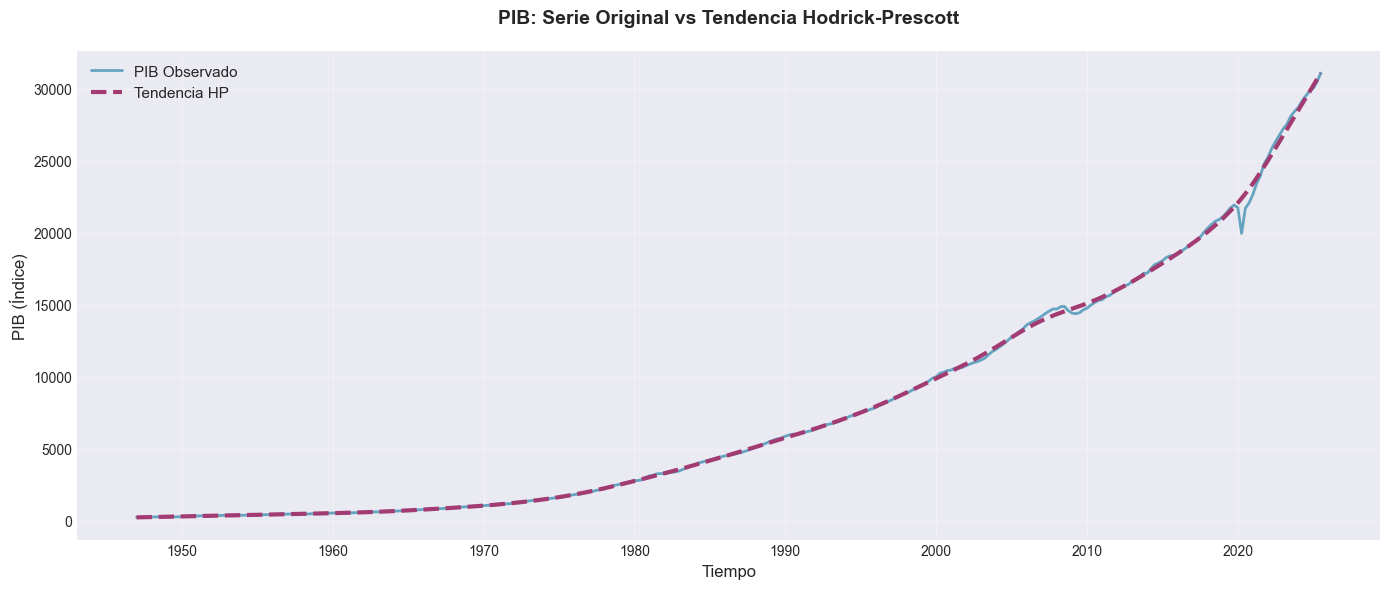

✓ Gráfico 1: Observa cómo la tendencia es suave y captura el crecimiento de largo plazo


In [9]:
# Gráfico 1: Original vs Tendencia
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(fechas, y, linewidth=2, label='PIB Observado', color='#2E86AB', alpha=0.7)
ax.plot(fechas, trend, linewidth=3, label='Tendencia HP', color='#A23B72', linestyle='--')

ax.set_title('PIB: Serie Original vs Tendencia Hodrick-Prescott', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Tiempo', fontsize=12)
ax.set_ylabel('PIB (Índice)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráfico 1: Observa cómo la tendencia es suave y captura el crecimiento de largo plazo")

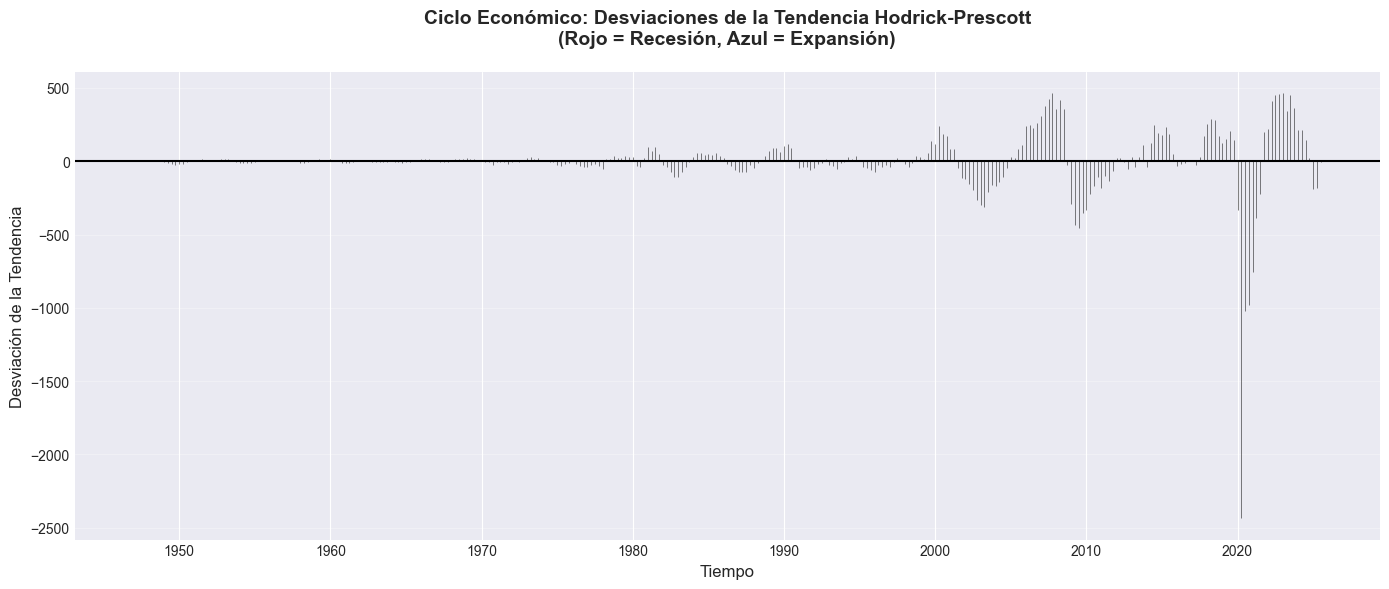

✓ Gráfico 2: Las barras rojas indican contracciones, las azules expansiones económicas


In [10]:
# Gráfico 2: El Ciclo Económico
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#D62828' if c < 0 else '#007FAA' for c in cycle]

ax.bar(fechas, cycle, color=colors, width=80, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-')

ax.set_title('Ciclo Económico: Desviaciones de la Tendencia Hodrick-Prescott\n' +
             '(Rojo = Recesión, Azul = Expansión)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Tiempo', fontsize=12)
ax.set_ylabel('Desviación de la Tendencia', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Gráfico 2: Las barras rojas indican contracciones, las azules expansiones económicas")

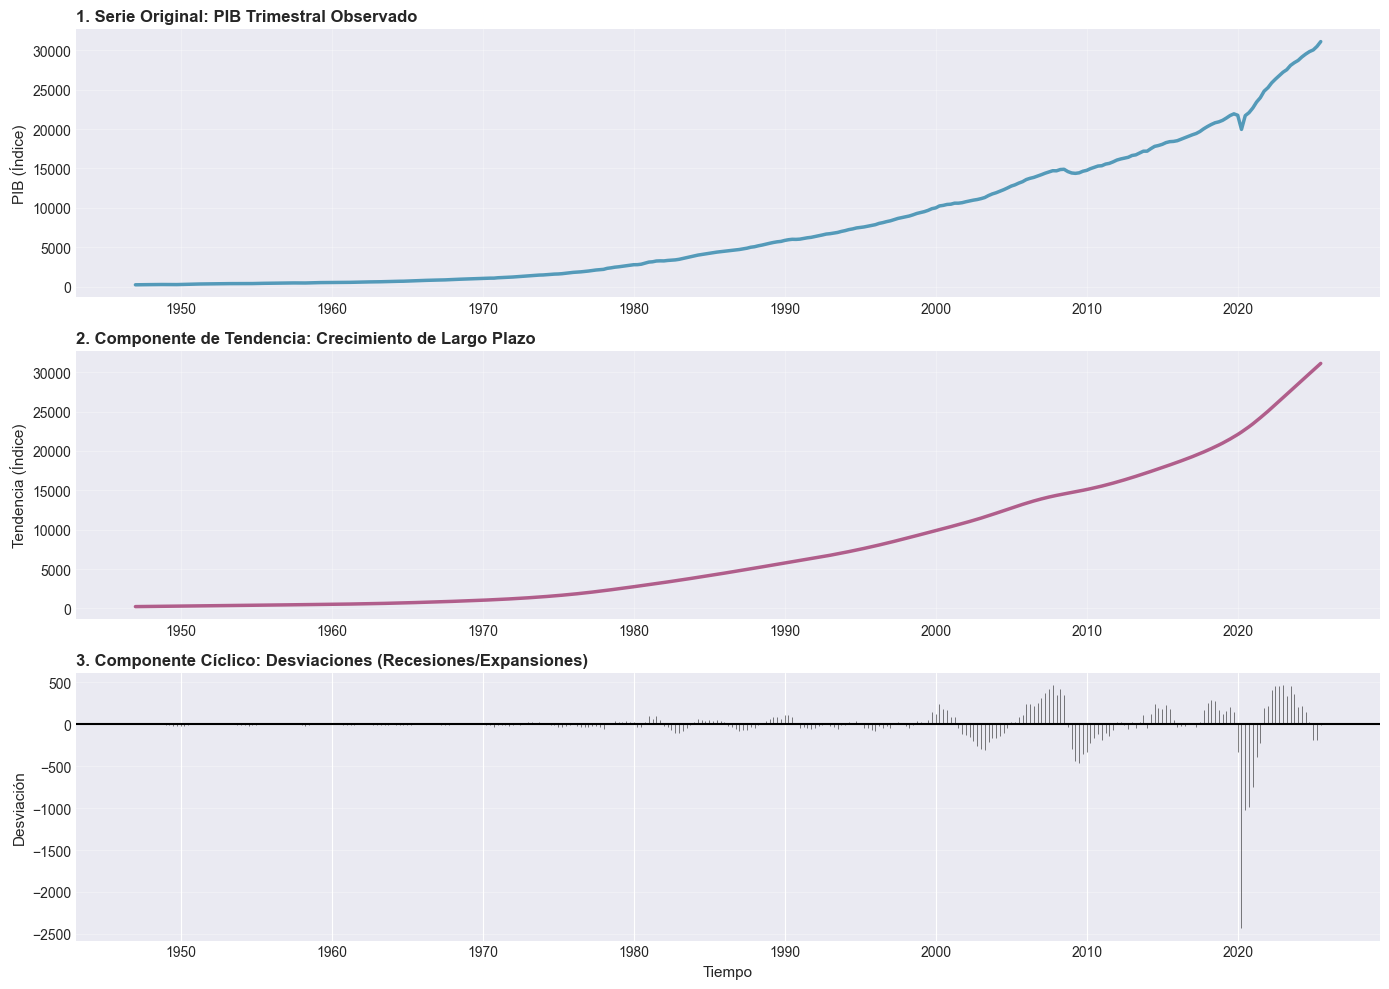

✓ Gráfico 3: Descomposición completa en tres paneles


In [11]:
# Gráfico 3: La Descomposición Completa
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Serie Original
axes[0].plot(fechas, y, linewidth=2.5, color='#2E86AB', alpha=0.8)
axes[0].set_title('1. Serie Original: PIB Trimestral Observado', 
                  fontsize=12, fontweight='bold', loc='left')
axes[0].set_ylabel('PIB (Índice)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Panel 2: Tendencia
axes[1].plot(fechas, trend, linewidth=2.5, color='#A23B72', alpha=0.8)
axes[1].set_title('2. Componente de Tendencia: Crecimiento de Largo Plazo', 
                  fontsize=12, fontweight='bold', loc='left')
axes[1].set_ylabel('Tendencia (Índice)', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Panel 3: Ciclo
colors = ['#D62828' if c < 0 else '#007FAA' for c in cycle]
axes[2].bar(fechas, cycle, color=colors, width=80, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].axhline(y=0, color='black', linewidth=1.5)
axes[2].set_title('3. Componente Cíclico: Desviaciones (Recesiones/Expansiones)', 
                  fontsize=12, fontweight='bold', loc='left')
axes[2].set_ylabel('Desviación', fontsize=11)
axes[2].set_xlabel('Tiempo', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Gráfico 3: Descomposición completa en tres paneles")

## Paso 6: Análisis e Interpretación

Ahora que hemos descompuesto la serie, veamos qué podemos entender de esto.

In [12]:
# Análisis cuantitativo
print("=" * 70)
print("ANÁLISIS DE LA DESCOMPOSICIÓN")
print("=" * 70)

print("\nESTADÍSTICAS DE LA TENDENCIA:")
print(f"  Crecimiento medio anualizado: {(np.diff(trend).mean() * 4):.2f} unidades/año")
print(f"  Crecimiento total (1947-2025): {((trend[-1] - trend[0]) / trend[0] * 100):.1f}%")
print(f"  Desviación estándar: {trend.std():.2f}")

print("\nESTADÍSTICAS DEL CICLO:")
print(f"  Desviación estándar: {cycle.std():.2f} (mide la amplitud del ciclo)")
print(f"  Mínimo (peor recesión): {cycle.min():.2f}")
print(f"  Máximo (mejor expansión): {cycle.max():.2f}")

# Porcentaje de tiempo en recesión
recession_pct = (cycle < 0).sum() / len(cycle) * 100
print(f"  % de trimestres en contracción: {recession_pct:.1f}%")

# Verificación: original = tendencia + ciclo
error = np.max(np.abs((y - trend - cycle)))
print(f"\n✓ Verificación (error de redondeo): {error:.2e}")
print(f"   (Debe ser ~0, confirma que y = g + c)")

# Correlación
corr_trend_original = np.corrcoef(y, trend)[0, 1]
corr_cycle_original = np.corrcoef(y, cycle)[0, 1]
print(f"\nCORRELACIONES:")
print(f"  Tendencia con original: {corr_trend_original:.3f} (muy alta, es esperado)")
print(f"  Ciclo con original: {corr_cycle_original:.3f}")
print(f"  Tendencia con ciclo: {np.corrcoef(trend, cycle)[0, 1]:.3f} (cercano a 0, es lo ideal)")

ANÁLISIS DE LA DESCOMPOSICIÓN

ESTADÍSTICAS DE LA TENDENCIA:
  Crecimiento medio anualizado: 393.17 unidades/año
  Crecimiento total (1947-2025): 12933.0%
  Desviación estándar: 8050.86

ESTADÍSTICAS DEL CICLO:
  Desviación estándar: 211.21 (mide la amplitud del ciclo)
  Mínimo (peor recesión): -2435.29
  Máximo (mejor expansión): 466.00
  % de trimestres en contracción: 48.9%

✓ Verificación (error de redondeo): 0.00e+00
   (Debe ser ~0, confirma que y = g + c)

CORRELACIONES:
  Tendencia con original: 1.000 (muy alta, es esperado)
  Ciclo con original: 0.038
  Tendencia con ciclo: 0.012 (cercano a 0, es lo ideal)


### Interpretación: ¿Qué Nos Dice el Ciclo?

Observando el gráfico del ciclo, podemos identificar eventos históricos importantes:

- **Finales de 1940s-1950s**: Leves fluctuaciones post-guerra
- **1970s**: Las recesiones del "shock petrolero" aparecen claramente
- **Años 1980s**: Ciclos más pronunciados
- **2008-2009**: La **Crisis Financiera Global** - la caída más profunda en toda la muestra
- **2020**: La **Pandemia de COVID-19** - caída dramática, recuperación rápida

El filtro HP nos ayuda a:

1. **Separar tendencia de ciclo**: Distinguimos el crecimiento sostenido de las perturbaciones temporales
2. **Identificar recesiones**: Los valores negativos corresponden a períodos de contracción económica
3. **Cuantificar amplitud**: Sabemos exactamente cuán lejos estamos de la tendencia

---

## Conclusión: El Poder del Filtro Hodrick-Prescott

Hemos implementado **manualmente** el filtro HP desde cero, sin librerías especializadas. Lo que hicimos fue:

1. **Construir una matriz D** que captura la "suavidad" de la serie
2. **Resolver un sistema de ecuaciones lineales** que equilibra:
   - Mantenerse cerca de los datos observados
   - Suavizar la trayectoria (penalizar cambios bruscos)
3. **Descomponer la serie** en tendencia + ciclo

### Por Qué Es Importante

- El **filtro HP** es la herramienta estándar en macroeconomía para analizar ciclos económicos
- Funciona bien en datos trimestrales (como los nuestros)
- Nos permite cuantificar y visualizar **recesiones y expansiones**

### Parámetro λ

El parámetro λ = 1,600 que usamos es el estándar recomendado para datos trimestrales. Si lo aumentamos, la tendencia sería más suave (menos sensible a cambios). Si lo disminuimos, sería más rígida.

### Próximos Pasos

Con estos componentes, ahora podemos:
- Estudiar las características del ciclo económico (duración, amplitud)
- Comparar ciclos entre países
- Construir modelos de predicción económica
- Analizar sincronización de ciclos con variables externas

¡Hemos descompuesto 78 años de historia económica en dos componentes interpretables!

---

**Nota metodológica**: Este ejercicio demuestra que no necesitamos "cajas negras" especializadas. Entender el álgebra lineal detrás del filtro HP nos da mayor control y comprensión de nuestros análisis.

In [10]:
# Guardamos los resultados en un DataFrame
resultados = pd.DataFrame({
    'observation_date': df['observation_date'],
    'original': y,
    'tendencia_hp': trend,
    'ciclo_hp': cycle
})

# Guardamos el archivo
ruta_salida = OUT_EXP / 'descomposicion_hp.csv'
resultados.to_csv(ruta_salida, index=False)

print("=" * 70)
print("RESULTADOS GUARDADOS")
print("=" * 70)
print(f"\n✓ Archivo guardado: {ruta_salida}")
print(f"\nÚltimas 5 observaciones:")
print(resultados.tail())

print("\n¡Ejercicio completado exitosamente!")
print("Has implementado el Filtro Hodrick-Prescott desde cero.")

RESULTADOS GUARDADOS

✓ Archivo guardado: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/exports/descomposicion_hp.csv

Últimas 5 observaciones:
    observation_date   original  tendencia_hp    ciclo_hp
310       2024-07-01  29511.664  29366.953158  144.710842
311       2024-10-01  29825.182  29801.106466   24.075534
312       2025-01-01  30042.113  30234.902793 -192.789793
313       2025-04-01  30485.729  30668.579554 -182.850554
314       2025-07-01  31098.027  31102.253674   -4.226674

¡Ejercicio completado exitosamente!
Has implementado el Filtro Hodrick-Prescott desde cero.
